# **RSDB Analysis**

In [18]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter
import yaml
import matplotlib.pyplot as plt
import librosa

In [32]:
# Load audio preprocessing constants from config.yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Load basic paths from config.yaml
DATA_FOLDER = os.path.join(os.getcwd(), config["paths"]["data_folder"])
AUDIO_FOLDER = os.path.join(os.getcwd(), config["paths"]["audio_folder"])
RAW_CYCLE_FOLDER_ORIGINAL = os.path.join(os.getcwd(), config["paths"]["raw_cycle_folder_original"])

SAMPLING_RATE = config["audio_processing"]["sampling_rate"] 
FRAME_LENGTH = config["audio_processing"]["frame_length"] 
HOP_LENGTH = config["audio_processing"]["hop_length"] 
FRAME_SIZE = int(FRAME_LENGTH*SAMPLING_RATE) 
HOP_SIZE = int(HOP_LENGTH*SAMPLING_RATE) 

DEVICES = ["AKGC417L", "LittC2SE", "Litt3200", "Meditron"]

### **Analysis of recordings**

Basic metadata statistics

Unique patients: 126
Average recordings per patient: 2.03



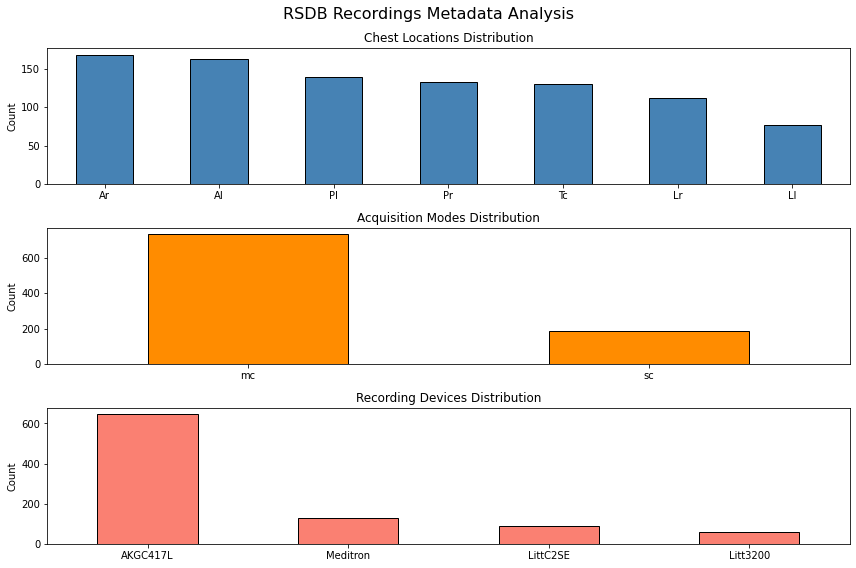

In [28]:
wav_files = [f for f in os.listdir(AUDIO_FOLDER) if f.endswith(".wav")]

# Parse filenames
records = []
for fname in wav_files:
    base = os.path.splitext(fname)[0]  
    parts = base.split("_")
    if len(parts) == 5:
        patient, rec_idx, location, mode, device = parts
        records.append({
            "Patient": patient,
            "RecordingIndex": rec_idx,
            "Location": location,
            "Mode": mode,
            "Device": device
        })

df = pd.DataFrame(records)

# Basic statistical data
summary = {
    "Patients (unique)": df["Patient"].nunique(),
    "Recordings per patient (avg)": df.groupby("Patient")["RecordingIndex"].nunique().mean(),
    "Locations": df["Location"].value_counts(),
    "Modes": df["Mode"].value_counts(),
    "Devices": df["Device"].value_counts()
}

print(f"Unique patients: {summary['Patients (unique)']}")
print(f"Average recordings per patient: {summary['Recordings per patient (avg)']:.2f}\n")

plt.figure(figsize=(12, 8))

# Locations
plt.subplot(3, 1, 1)
df["Location"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Chest Locations Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Acquisition modes
plt.subplot(3, 1, 2)
df["Mode"].value_counts().plot(kind="bar", color="darkorange", edgecolor="black")
plt.title("Acquisition Modes Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Devices
plt.subplot(3, 1, 3)
df["Device"].value_counts().plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Recording Devices Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.suptitle("RSDB Recordings Metadata Analysis", fontsize=16)
plt.tight_layout()
plt.show()

Distribution of recordings durations

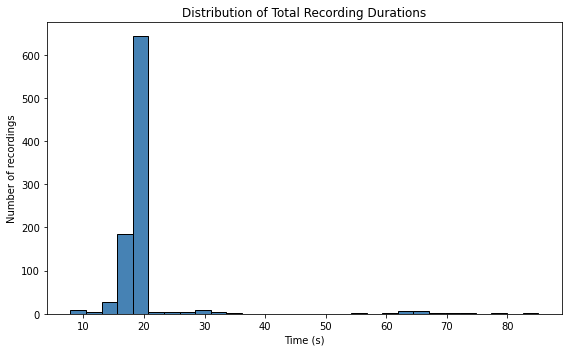

In [36]:
recording_durations = []

for file in os.listdir(AUDIO_FOLDER):
    if file.endswith(".txt"):
        txt_path = os.path.join(AUDIO_FOLDER, file)
        annotations = np.loadtxt(txt_path)

        if annotations.ndim == 1: 
            annotations = annotations[np.newaxis, :]

        start_min = np.min(annotations[:, 0])
        end_max = np.max(annotations[:, 1])
        total_duration = end_max - start_min

        if total_duration > 0:
            recording_durations.append(total_duration)

plt.figure(figsize=(8, 5))
plt.hist(recording_durations, bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Total Recording Durations")
plt.xlabel("Time (s)")
plt.ylabel("Number of recordings")
plt.tight_layout()
plt.show()

### **Analysis of demographic data from recordings**

Basic demographic statistics

In [46]:
demo_data = "demographic_info.txt"
cols = ["PatientID", "Age", "Sex", "BMI", "Weight", "Height"]
df_demo = pd.read_csv(demo_data, sep="\s+", names=cols, na_values="NA")

# Overview
print(df_demo.head())
print(df_demo.info())

   PatientID    Age Sex    BMI  Weight  Height
0        101   3.00   F    NaN    19.0    99.0
1        102   0.75   F    NaN     9.8    73.0
2        103  70.00   F  33.00     NaN     NaN
3        104  70.00   F  28.47     NaN     NaN
4        105   7.00   F    NaN    32.0   135.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PatientID  126 non-null    int64  
 1   Age        125 non-null    float64
 2   Sex        125 non-null    object 
 3   BMI        75 non-null     float64
 4   Weight     44 non-null     float64
 5   Height     42 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 6.0+ KB
None


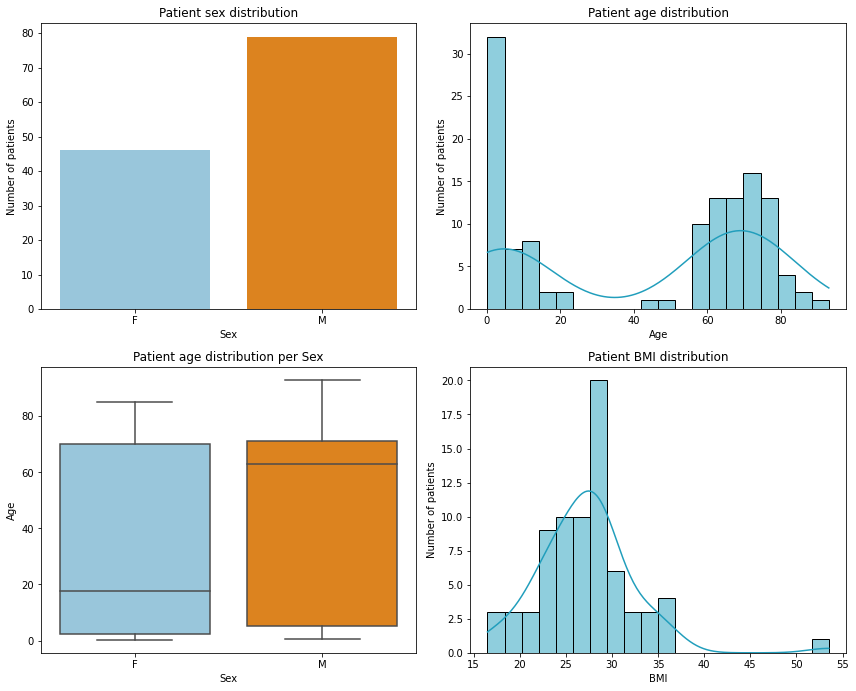

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sex distribution
sns.countplot(data=df_demo, x="Sex", palette=["#8ecae6", "#fb8500"], ax=axes[0,0])
axes[0,0].set_title("Patient sex distribution")
axes[0,0].set_ylabel("Number of patients")

# Age distribution
sns.histplot(df_demo["Age"].dropna(), bins=20, kde=True, color="#219ebc", ax=axes[0,1])
axes[0,1].set_title("Patient age distribution")
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("Number of patients")

# Age per Sex
sns.boxplot(data=df_demo, x="Sex", y="Age", palette=["#8ecae6", "#fb8500"], ax=axes[1,0])
axes[1,0].set_title("Patient age distribution per Sex")

# BMI distribution
sns.histplot(df_demo["BMI"].dropna(), bins=20, kde=True, color="#219ebc", ax=axes[1,1])
axes[1,1].set_title("Patient BMI distribution")
axes[1,1].set_xlabel("BMI")
axes[1,1].set_ylabel("Number of patients")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Correlation of demographic data with recordings

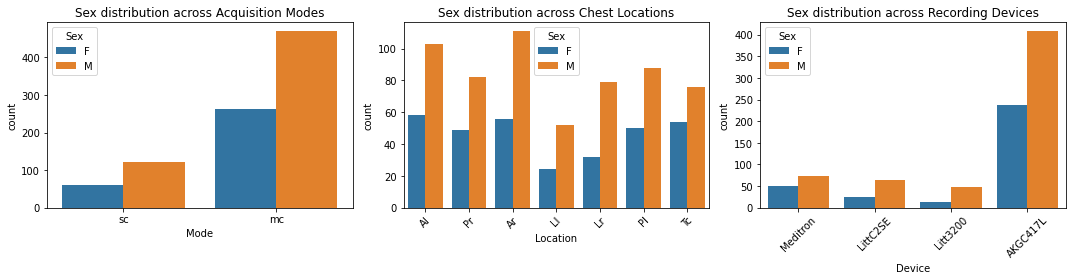

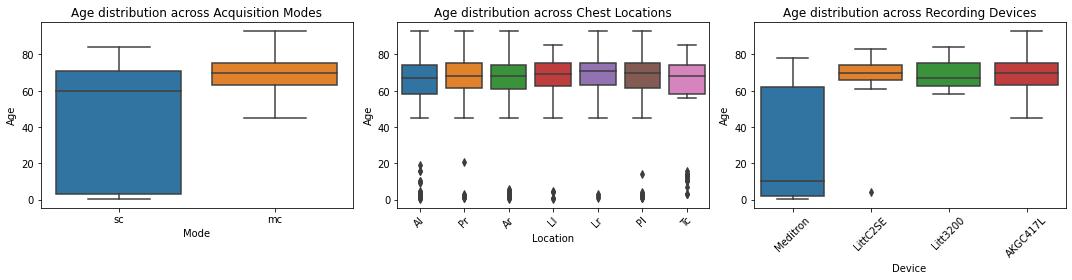

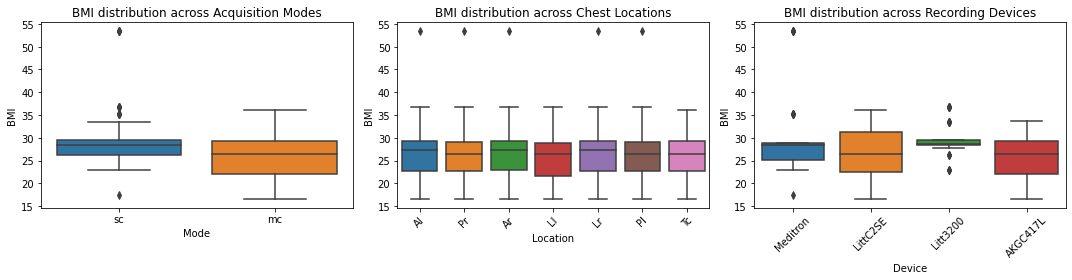

In [ ]:
df["Patient"] = df["Patient"].astype(int)

# Merge recording and demographic dataframes
df_merged = df.merge(df_demo, left_on="Patient", right_on="PatientID", how="inner")

# SEX vs acquisition methods, locations, devices 
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.countplot(data=df_merged, x="Mode", hue="Sex")
plt.title("Sex distribution across Acquisition Modes")

plt.subplot(1,3,2)
sns.countplot(data=df_merged, x="Location", hue="Sex")
plt.title("Sex distribution across Chest Locations")
plt.xticks(rotation=45)

plt.subplot(1,3,3)
sns.countplot(data=df_merged, x="Device", hue="Sex")
plt.title("Sex distribution across Recording Devices")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# AGE vs acquisition methods, locations, devices 
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.boxplot(data=df_merged, x="Mode", y="Age")
plt.title("Age distribution across Acquisition Modes")

plt.subplot(1,3,2)
sns.boxplot(data=df_merged, x="Location", y="Age")
plt.title("Age distribution across Chest Locations")
plt.xticks(rotation=45)

plt.subplot(1,3,3)
sns.boxplot(data=df_merged, x="Device", y="Age")
plt.title("Age distribution across Recording Devices")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# BMI vs acquisition methods, locations, devices
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.boxplot(data=df_merged, x="Mode", y="BMI")
plt.title("BMI distribution across Acquisition Modes")

plt.subplot(1,3,2)
sns.boxplot(data=df_merged, x="Location", y="BMI")
plt.title("BMI distribution across Chest Locations")
plt.xticks(rotation=45)

plt.subplot(1,3,3)
sns.boxplot(data=df_merged, x="Device", y="BMI")
plt.title("BMI distribution across Recording Devices")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Analysis of cycles from recordings**

Distribution of cycles durations

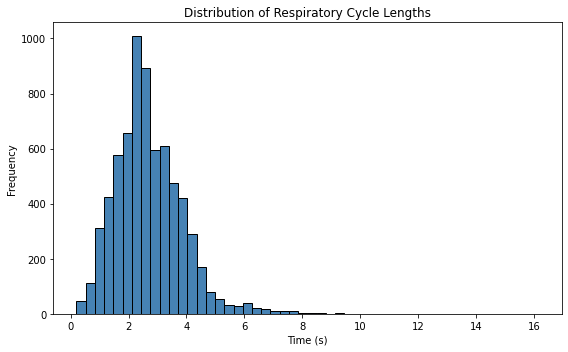

In [31]:
from utils.audio_preprocessing import classify

records = []

for file in os.listdir(AUDIO_FOLDER):
    if file.endswith(".txt"):
        txt_path = os.path.join(AUDIO_FOLDER, file)
        annotations = np.loadtxt(txt_path)

        if annotations.ndim == 1:
            annotations = annotations.reshape(1, -1)

        for (start, end, crackle, wheeze) in annotations:
            duration = end - start
            if duration > 0:
                label = classify(int(crackle), int(wheeze))
                matched_device = next((d for d in DEVICES if d in file), "Unknown")

                records.append({
                    "file": file.replace(".txt", ".wav"),
                    "duration": duration,
                    "label": label,
                    "device": matched_device
                })

df_cycles = pd.DataFrame(records)

plt.figure(figsize=(8, 5))
plt.hist(df_cycles["duration"], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribution of Respiratory Cycle Lengths")
plt.xlabel("Time (s)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Distribution of cycles per class

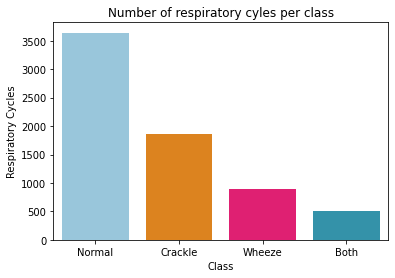

In [ ]:
class_colors = {
    "Normal": "#8ecae6",
    "Crackle": "#fb8500",
    "Wheeze": "#ff006e",
    "Both": "#219ebc"
}

plt.figure(figsize=(6,4))
sns.countplot(data=df_cycles, x="label", order=df_cycles["label"].value_counts().index, palette=class_colors)
plt.xlabel("Class")
plt.ylabel("Respiratory Cycles")
plt.title("Number of respiratory cyles per class")
plt.show()

### **Analysis of recording devices**

Magnitude responce of each device to visualize their behaviour

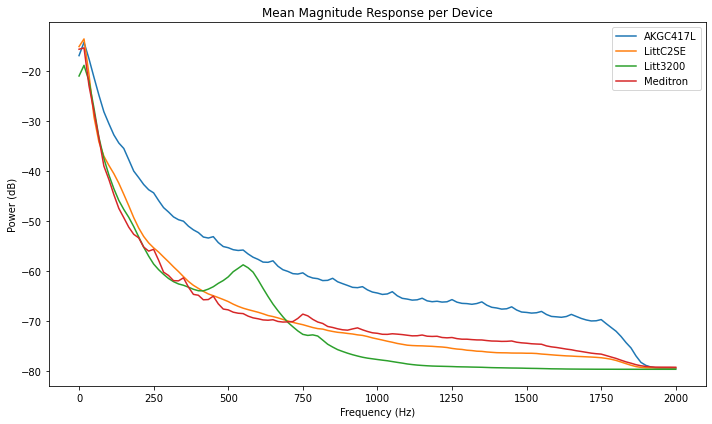

In [33]:
device_signals = {d: [] for d in DEVICES}

for fname in os.listdir(RAW_CYCLE_FOLDER_ORIGINAL):
    if fname.endswith(".wav"):
        device = next((d for d in DEVICES if d in fname), None)
        if device:
            y, _ = librosa.load(os.path.join(RAW_CYCLE_FOLDER_ORIGINAL, fname), sr=SAMPLING_RATE)
            device_signals[device].append(y)

# Calculate the mean magnitude response of each device
plt.figure(figsize=(10, 6))

for device in DEVICES:
    signals = device_signals[device]

    all_psd = []
    for y in signals:
        # STFT to Power Spectrogram
        S = np.abs(librosa.stft(y, n_fft=FRAME_SIZE, hop_length=HOP_SIZE))**2
        S_db = librosa.power_to_db(S, ref=np.max)
        mean_spectrum = np.mean(S_db, axis=1)  # Get mean value over time
        all_psd.append(mean_spectrum)

    avg_psd = np.mean(np.stack(all_psd), axis=0)
    freqs = librosa.fft_frequencies(sr=SAMPLING_RATE, n_fft=FRAME_SIZE)
    plt.plot(freqs, avg_psd, label=device)

plt.title("Mean Magnitude Response per Device")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.legend()
plt.tight_layout()
plt.show()

Distribution of cycles per device

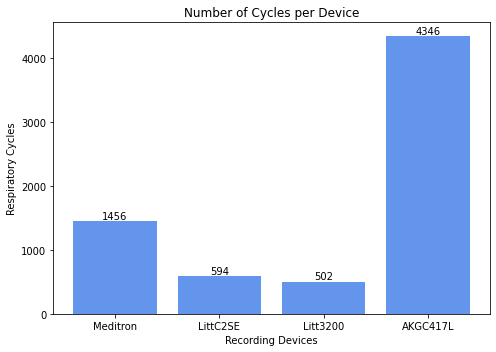

In [34]:
# Count cycles per device 
device_counts_cyc = Counter()
for fname in os.listdir(RAW_CYCLE_FOLDER_ORIGINAL):
    if fname.endswith(".wav"):
        matched_device = next((d for d in DEVICES if d in fname), None)
        if matched_device:
            device_counts_cyc[matched_device] += 1

plt.figure(figsize=(7, 5))
plt.bar(device_counts_cyc.keys(), device_counts_cyc.values(), color="cornflowerblue")
plt.title("Number of Cycles per Device")
plt.xlabel("Recording Devices")
plt.ylabel("Respiratory Cycles")

for i, (device, count) in enumerate(device_counts_cyc.items()):
    plt.text(i, count + 1, str(count), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

Distribution of cycles per device and class

In [30]:
# class × device table
device_class_counts = (
    df_cycles.groupby(["label", "device"])
    .size()
    .unstack(fill_value=0)
    .astype(int)
)

print(device_class_counts)

device   AKGC417L  Litt3200  LittC2SE  Meditron
label                                          
Both          381        25        44        56
Crackle      1543        29        77       215
Normal       1922       336       347      1037
Wheeze        500       112       126       148
